## Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from sklearn import preprocessing
import numpy as np
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from transformers import BertTokenizer, BertModel
import torch
import torch.nn as nn

# load_aokvqa.py
import os
import json

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_aokvqa(aokvqa_dir, split, version='v1p0'):
    assert split in ['train', 'val', 'test', 'test_w_ans']
    dataset = json.load(open(
        os.path.join(aokvqa_dir, f"aokvqa_{version}_{split}.json")
    ))
    return dataset

def get_coco_path(split, image_id, coco_dir):
    return os.path.join(coco_dir, f"{split}2017", f"{image_id:012}.jpg")

AOKVQA_DIR="datasets/aokvqa/"
COCO_DIR="datasets/coco2017/"
aokvqa_dir = f"./aokvqa/{AOKVQA_DIR}"
coco_dir = f"./aokvqa/{COCO_DIR}"

/opt/conda/envs/r3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
get_coco_path("val", 461751, coco_dir)

'./aokvqa/datasets/coco2017/val2017/000000461751.jpg'

In [3]:
def subsample(dataset, n_samples=None, frac=None, random_seed=42):
    random.seed(random_seed)
    if n_samples:
        return random.sample(dataset, n_samples)
    elif frac:
        sample_size = int(len(dataset) * frac)
        return random.sample(dataset, sample_size)
    return dataset

In [4]:
USE_SUBSET_DATA = False 
train_dataset = load_aokvqa(aokvqa_dir, 'train')  
val_dataset = load_aokvqa(aokvqa_dir, 'val')
test_dataset = load_aokvqa(aokvqa_dir, 'test')
print(f"Full Train aokvqa: {len(train_dataset)}")
print(f"Full Val aokvqa: {len(val_dataset)}")
print(f"Full Test aokvqa: {len(test_dataset)}")

if USE_SUBSET_DATA:
    train_dataset = subsample(train_dataset, frac=0.2)
    val_dataset = subsample(val_dataset, frac=0.2)
    test_dataset = subsample(test_dataset, frac=0.2)
    print(f"Used Train aokvqa: {len(train_dataset)}")
    print(f"Used Val aokvqa: {len(val_dataset)}")
    print(f"Used Test aokvqa: {len(test_dataset)}")

Full Train aokvqa: 17056
Full Val aokvqa: 1145
Full Test aokvqa: 6702


## Data Preparation

Fields Considered:

- Question
- Choices
- Correct answer
- Correct Choice Indice
- Rationale
- Direct answer

In [5]:
qa_data = []
for sample in val_dataset:
    question_id = sample["question_id"]
    image_id = sample["image_id"]
    question = sample["question"]
    choices = sample["choices"]
    correct_choice_idx = sample["correct_choice_idx"]
    rationales = sample.get("rationales", [])
    combined_rationale = " ".join(rationales)
    direct_answers = sample.get("direct_answers", [])
    combined_direct_answer = "\t".join(direct_answers)
    correct_ans = choices[correct_choice_idx]
    qa_data.append({
        "question_id": question_id,
        "image_id": image_id,
        "question": question,
        "choices": choices,
        "correct_answer": correct_ans,
        "correct_choice_idx": correct_choice_idx,
        "rationale": combined_rationale,
        "direct_answer": combined_direct_answer
    })
qa_df = pd.DataFrame(qa_data)

In [6]:
qa_df.head()


,question_id,image_id,question,choices,correct_answer,correct_choice_idx,rationale,direct_answer
0,22jbM6gDxdaMaunuzgrsBB,461751,What is in the motorcyclist's mouth?,"[toothpick, food, popsicle stick, cigarette]",cigarette,3,He's smoking while riding. The motorcyclist ha...,cigarette\tcigarette\tcigarette\tcigarette\tci...
1,2Aq5RiEn7eyfWjEbpuYT2o,377368,Which number birthday is probably being celebr...,"[one, ten, nine, thirty]",thirty,3,There is a birthday cake on the table with the...,thirty\t30th\tthirty\tthirty\tthirty\t30th\tth...
2,2Br4bJfKY7SQM9DECrqqeG,563603,What best describes the pool of water?,"[frozen, fresh, dirty, boiling]",dirty,2,The pool is dark brown. It it brown and surrou...,muddy\tdirty\tmurky water\tmuddy\tpond\tpond\t...
3,2C8riXpRLX3CyM5jDz23m7,329542,What is the white substance on top of the cupc...,"[butter, mayo, ice cream, icing]",icing,3,This is frosting used to decorate and add more...,icing\twhipped cream\ticing\tfrosting\ticing\t...
4,2DQex53EkNGH2cfo3WPuPn,182202,What type of device is sitting next to the lap...,"[mouse, mobile phone, pen, keyboard]",mobile phone,1,It has the name of it on the top The device ha...,cell phone\tvodafone\tphone\tphone\tphone\tpho...


## Multimodal

### CLIP

In [6]:
def get_clip_prediction(img_path, choices, question):
    # Load and preprocess the image
    image = Image.open(img_path).convert("RGB")
    image_input = preprocess(image).unsqueeze(0).to(device)
    
    # Tokenize the list of candidate text choices
    # text_input = clip.tokenize(choices).to(device)
    text_input = torch.cat([
        clip.tokenize(f"{question} Answer: {c}") for c in choices
    ]).to(device)
    # print(str(text_input))
    
    with torch.no_grad():
        # Compute image and text features
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_input)
        
        # Normalize features to unit length (recommended for cosine similarity)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Compute similarity between the image and each text choice
        similarity = (image_features @ text_features.T).squeeze(0)

        confidence_scores = torch.softmax(similarity, dim=0).cpu().numpy()
    
    # Return the choice with the highest similarity score
    best_idx = similarity.argmax().item()
    best_answer = choices[best_idx]
    best_confidence = confidence_scores[best_idx]
    
    return best_answer, best_confidence

In [7]:
import torch
import clip
from PIL import Image
from tqdm import tqdm

# Set up device and load the CLIP model along with its preprocessing pipeline.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# Process each sample in qa_data and compute predictions
predictions = []
condifence_scores = []
for sample in tqdm(qa_data, desc="Processing Images"):
    image_id = sample['image_id']
    img_path = get_coco_path('val', image_id, coco_dir)
    choices  = sample['choices'] 
    prediction, confidence = get_clip_prediction(img_path, choices, sample['question'])
    predictions.append(prediction)
    condifence_scores.append(confidence)

qa_df['clip_baseline_prediction'] = predictions
qa_df['clip_baseline_confidence'] = condifence_scores


Processing Images: 100%|██████████| 1145/1145 [02:24<00:00,  7.90it/s]


In [11]:
correctness = (qa_df['clip_baseline_prediction'] == qa_df['correct_answer'])
accuracy = correctness.mean()
calibration_error = (qa_df['clip_baseline_confidence'] - correctness).abs().mean()
print(f"CLIP Baseline Accuracy: {accuracy:.2%}")
print(f"CLIP Baseline Calibration Error: {calibration_error:.2%}")

CLIP Baseline Accuracy: 54.93%
CLIP Baseline Calibration Error: 52.29%


In [8]:
qa_df.to_pickle("CLIP_result.pkl")

# VisualBERT
## Multiple Choice (no use, trash)

In [78]:
def extract_visual_features(img_path, max_regions=36):
    """Extract region features using Faster R-CNN's ROI heads and upsample to 2048 dimensions."""
    img = Image.open(img_path).convert("RGB")
    img_array = np.array(img)
    
    # Create a linear layer to upsample features from 1028 to 2048
    upsample_layer = nn.Linear(1028, 2048).to(device)
    
    with torch.no_grad():
        # Prepare input for Detectron2
        height, width = img_array.shape[:2]
        inputs = [{"image": torch.as_tensor(img_array).permute(2, 0, 1).to(device), 
                   "height": height, 
                   "width": width}]
        
        # Run detector
        images = predictor.model.preprocess_image(inputs)
        features = predictor.model.backbone(images.tensor)
        proposals, _ = predictor.model.proposal_generator(images, features)

        # Get ROI features
        box_features = predictor.model.roi_heads.box_pooler(
            [features[f] for f in predictor.model.roi_heads.box_in_features],
            [p.proposal_boxes for p in proposals]
        )
        roi_features = predictor.model.roi_heads.box_head(box_features)

        # Get top-k proposals by objectness score
        scores = proposals[0].objectness_logits.sigmoid().cpu().numpy()
        top_k = min(max_regions, len(scores))
        indices = np.argsort(scores)[-top_k:]
        
        # Extract top-k boxes & features
        boxes = proposals[0].proposal_boxes.tensor[indices].cpu().numpy()
        features = roi_features[indices].cpu().numpy()  # Shape: [N, feature_dim]
        
        # Normalize bounding boxes
        boxes[:, 2] -= boxes[:, 0]  # x2 -> w
        boxes[:, 3] -= boxes[:, 1]  # y2 -> h
        boxes[:, [0, 2]] /= width    # Normalize x, w
        boxes[:, [1, 3]] /= height   # Normalize y, h
        
        # Combine features and boxes
        visual_embeds = np.concatenate([features, boxes], axis=1)
        visual_embeds = torch.from_numpy(visual_embeds).float().unsqueeze(0).to(device)

        # Upsample the visual embeddings from 1028 to 2048
        visual_embeds = upsample_layer(visual_embeds.squeeze(0))  # Remove batch dim before applying Linear layer
        visual_embeds = visual_embeds.unsqueeze(0)  # Add back batch dim
    
    return visual_embeds

In [157]:
import torch
import numpy as np
from PIL import Image

def visualbert_answer(img_path, question, choices=None):
    """Run VisualBERT for multiple-choice or direct answering with confidence scores."""
    visual_embeds = extract_visual_features(img_path)
    visual_attention_mask = torch.ones(visual_embeds.shape[:2]).to(device)
    visual_token_type_ids = torch.ones(visual_embeds.shape[:2]).to(device)

    # Multiple-choice processing
    input_ids, attention_masks, token_type_ids = [], [], []
    print(choices)
    for choice in choices:
        text = f"{question} [SEP] {choice}"
        inputs = tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            max_length=128,
            truncation=True
        )
        print(len(inputs["input_ids"]))
        input_ids.append(inputs["input_ids"])
        attention_masks.append(inputs["attention_mask"])
        token_type_ids.append(inputs["token_type_ids"])
    # print(input_ids[0])
    input_ids = torch.cat(input_ids, dim=0).to(device)
    print(input_ids.shape)
    attention_mask = torch.cat(attention_masks, dim=0).to(device)
    token_type_ids = torch.cat(token_type_ids, dim=0).to(device)
    
    print(visual_embeds.shape)
    print(visual_attention_mask.shape)
    print(visual_token_type_ids.shape)
    with torch.no_grad():
        batch_size = input_ids.shape[0]  # Number of choices
        visual_embeds = visual_embeds.expand(batch_size, -1, -1)  # Expand visual features
        visual_attention_mask = visual_attention_mask.expand(batch_size, -1)
        visual_token_type_ids = visual_token_type_ids.expand(batch_size, -1)

        print(input_ids.dtype)
        print(attention_mask.dtype)
        print(token_type_ids.dtype)
        print(visual_embeds.dtype)
        print(visual_attention_mask.dtype)
        print(visual_token_type_ids.dtype)
        print(input_ids.shape)
        print(attention_mask.shape)
        print(token_type_ids.shape)
        print(visual_embeds.shape)
        print(visual_attention_mask.shape)
        print(visual_token_type_ids.shape)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            visual_embeds=visual_embeds.float(),
            visual_attention_mask=visual_attention_mask.long(),
            visual_token_type_ids=visual_token_type_ids.long(),
        )
        logits = outputs.logits
        choice_confidence_scores = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    best_idx = logits.argmax().item()
    # return choices[best_idx], float(choice_confidence_scores[best_idx])

    # Direct answering
    inputs = tokenizer(
        question,
        return_tensors="pt",
        padding="max_length",
        max_length=128,
        truncation=True
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    token_type_ids = inputs["token_type_ids"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids,
            output_hidden_states=True,  # Get token probabilities
            return_dict=True
        )
        logits = outputs.logits  # Get token logits
        probs = torch.softmax(logits, dim=-1)  # Convert logits to probabilities

        # Generate answer
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids,
            max_length=20
        )
        direct_answer = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        # Compute confidence as mean probability of generated tokens
        generated_probs = probs[0, torch.arange(len(generated_ids[0])), generated_ids[0]]
        confidence_score = float(torch.mean(generated_probs).item())

        return choices[best_idx], float(choice_confidence_scores[best_idx]), direct_answer, confidence_score


In [133]:
    # print(input_ids.shape)
    # print(attention_mask.shape)
    # print(token_type_ids.shape)
    # print(visual_embeds.shape)
    # print(visual_attention_mask.shape)
    # print(visual_token_type_ids.shape)

In [134]:
import torch
from PIL import Image
from transformers import VisualBertForMultipleChoice, BertTokenizer
from torchvision import transforms

model = VisualBertForMultipleChoice.from_pretrained("uclanlp/visualbert-vqa", ignore_mismatched_sizes=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")  # VisualBERT uses BERT's tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

import torch
import numpy as np
from PIL import Image
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg

# Initialize Faster R-CNN detector
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set confidence threshold
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml")  # Use COCO weights
cfg.MODEL.ROI_HEADS.OUTPUT_FEATURES = True
predictor = DefaultPredictor(cfg)

Some weights of VisualBertForMultipleChoice were not initialized from the model checkpoint at uclanlp/visualbert-vqa and are newly initialized because the shapes did not match:
- cls.weight: found shape torch.Size([3129, 768]) in the checkpoint and torch.Size([1, 768]) in the model instantiated
- cls.bias: found shape torch.Size([3129]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [159]:
# Process each sample in qa_data and compute predictions
choices_pred = []
choice_confidences = []
direct_answers = []
direct_confidences = []
for sample in tqdm(qa_data, desc="Processing Images"):
    image_id = sample['image_id']
    img_path = get_coco_path('val', image_id, coco_dir)
    choices  = sample['choices'] 
    choice, confidence_choice, direct, confident_direct = visualbert_answer(img_path, sample['question'], choices)
    choices_pred.append(choice)
    choice_confidences.append(confidence_choice)
    direct_answers.append(direct)
    direct_confidences.append(confident_direct)


qa_df['VisualBERT_multiple_choice_prediction'] = choices_pred
qa_df['VisualBERT_multiple_choice_prediction_confidence'] = choice_confidences
qa_df['VisualBERT_direct_answers_prediction'] = direct_answers
qa_df['VisualBERT_direct_answers_prediction_confidence'] = direct_confidences

Processing Images:   0%|          | 0/1145 [00:00<?, ?it/s]

['toothpick', 'food', 'popsicle stick', 'cigarette']
1
1
1
1
torch.Size([4, 128])
torch.Size([1, 36, 2048])
torch.Size([1, 36])
torch.Size([1, 36])
torch.int64
torch.int64
torch.int64
torch.float32
torch.float32
torch.float32
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 36, 2048])
torch.Size([4, 36])
torch.Size([4, 36])


RuntimeError: shape '[-1, 128]' is invalid for input of size 4

# NEW
## one image demo

In [ ]:
import io

import numpy as np
import PIL.Image
import torch
from IPython.display import Image, display
from modeling_frcnn import GeneralizedRCNN
from processing_image import Preprocess
from visualizing_image import SingleImageViz

import utils
from transformers import BertTokenizerFast, VisualBertForQuestionAnswering
from utils import Config


# URL = "https://raw.githubusercontent.com/airsplay/py-bottom-up-attention/master/demo/data/images/input.jpg"
URL = "https://vqa.cloudcv.org/media/test2014/COCO_test2014_000000262567.jpg"
OBJ_URL = "https://raw.githubusercontent.com/airsplay/py-bottom-up-attention/master/demo/data/genome/1600-400-20/objects_vocab.txt"
ATTR_URL = "https://raw.githubusercontent.com/airsplay/py-bottom-up-attention/master/demo/data/genome/1600-400-20/attributes_vocab.txt"
VQA_URL = "https://dl.fbaipublicfiles.com/pythia/data/answers_vqa.txt"


# for visualizing output
def showarray(a, fmt="jpeg"):
    a = np.uint8(np.clip(a, 0, 255))
    f = io.BytesIO()
    PIL.Image.fromarray(a).save(f, fmt)
    display(Image(data=f.getvalue()))

In [164]:
objids = utils.get_data(OBJ_URL)
attrids = utils.get_data(ATTR_URL)
vqa_answers = utils.get_data(VQA_URL)

In [165]:
frcnn_cfg = Config.from_pretrained("unc-nlp/frcnn-vg-finetuned")

frcnn = GeneralizedRCNN.from_pretrained("unc-nlp/frcnn-vg-finetuned", config=frcnn_cfg)

image_preprocess = Preprocess(frcnn_cfg)

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
visualbert_vqa = VisualBertForQuestionAnswering.from_pretrained("uclanlp/visualbert-vqa")

%s not found in cache or force_download set to True, downloading to %s https://s3.amazonaws.com/models.huggingface.co/bert/unc-nlp/frcnn-vg-finetuned/config.yaml /home/ubuntu/.cache/torch/transformers/tmpy_drz_w1


Downloading: 100%|██████████| 2.13k/2.13k [00:00<00:00, 4.39MB/s]

loading configuration file cache
%s not found in cache or force_download set to True, downloading to %s https://cdn.huggingface.co/unc-nlp/frcnn-vg-finetuned/pytorch_model.bin /home/ubuntu/.cache/torch/transformers/tmpsb4lrgge



Downloading: 100%|██████████| 262M/262M [00:05<00:00, 45.8MB/s] 


loading weights file https://cdn.huggingface.co/unc-nlp/frcnn-vg-finetuned/pytorch_model.bin from cache at /home/ubuntu/.cache/torch/transformers/57f6df6abe353be2773f2700159c65615babf39ab5b48114d2b49267672ae10f.77b59256a4cf8343ae0f923246a81489fc8d82f98d082edc2d2037c977c0d9d0
All model checkpoint weights were used when initializing GeneralizedRCNN.

All the weights of GeneralizedRCNN were initialized from the model checkpoint at unc-nlp/frcnn-vg-finetuned.
If your task is similar to the task the model of the checkpoint was trained on, you can already use GeneralizedRCNN for predictions without further training.


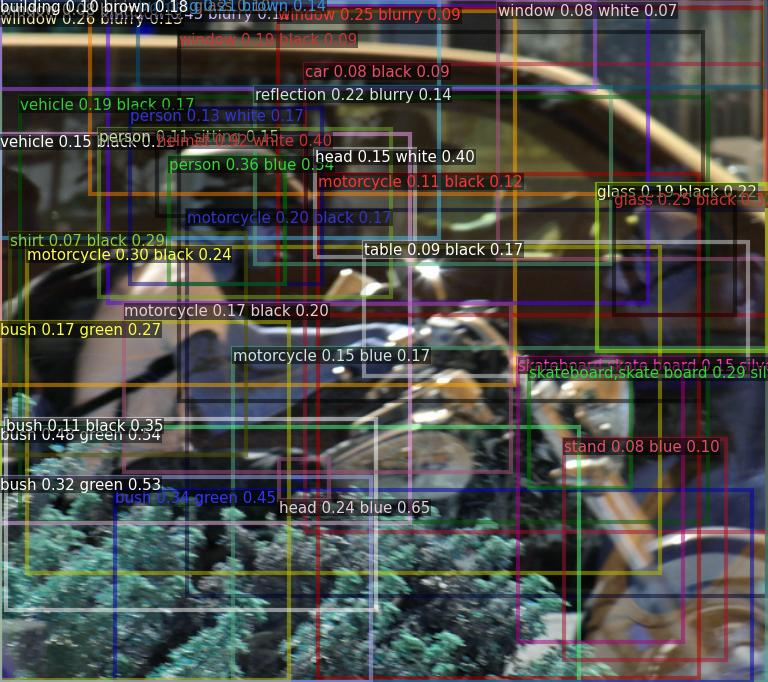

In [169]:
# image viz
URL = "./aokvqa/datasets/coco2017/val2017/000000461751.jpg"
frcnn_visualizer = SingleImageViz(URL, id2obj=objids, id2attr=attrids)
# run frcnn
images, sizes, scales_yx = image_preprocess(URL)
output_dict = frcnn(
    images,
    sizes,
    scales_yx=scales_yx,
    padding="max_detections",
    max_detections=frcnn_cfg.max_detections,
    return_tensors="pt",
)
# add boxes and labels to the image

frcnn_visualizer.draw_boxes(
    output_dict.get("boxes"),
    output_dict.pop("obj_ids"),
    output_dict.pop("obj_probs"),
    output_dict.pop("attr_ids"),
    output_dict.pop("attr_probs"),
)
showarray(frcnn_visualizer._get_buffer())

In [206]:
# test_questions_for_url1 = [
#     "Where is this scene?",
#     "what is the man riding?",
#     "What is the man wearing?",
#     "What is the color of the horse?"
# ]
test_questions_for_url2 = [
    "Where is the cat?",
    "What is near the disk?",
    "What is the color of the table?",
    "What is the color of the cat?",
    "What is the shape of the monitor?",
    "What is in the motorcyclist's mouth?",
]

# Very important that the boxes are normalized
# normalized_boxes = output_dict.get("normalized_boxes")
features = output_dict.get("roi_features")

In [205]:
for test_question in test_questions_for_url2:
    test_question = [test_question]

    inputs = bert_tokenizer(
        test_question,
        padding="max_length",
        max_length=20,
        truncation=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        add_special_tokens=True,
        return_tensors="pt",
    )

    output_vqa = visualbert_vqa(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        visual_embeds=features,
        visual_attention_mask=torch.ones(features.shape[:-1]),
        token_type_ids=inputs.token_type_ids,
        output_attentions=False,
    )
    # get prediction
    pred_vqa = output_vqa["logits"].argmax(-1)
    print("Question:", test_question)
    print("prediction from VisualBert VQA:", vqa_answers[pred_vqa])

Question: ['Where is the cat?']
prediction from VisualBert VQA: no cat
Question: ['What is near the disk?']
prediction from VisualBert VQA: nothing
Question: ['What is the color of the table?']
prediction from VisualBert VQA: brown
Question: ['What is the color of the cat?']
prediction from VisualBert VQA: gray
Question: ['What is the shape of the monitor?']
prediction from VisualBert VQA: square
Question: ["What is in the motorcyclist's mouth?"]
prediction from VisualBert VQA: nothing
Question: ["What is in the motorcyclist's mouth? Answer 1 for cigarette, 2 for popsicle stick"]
prediction from VisualBert VQA: nothing


## whole validation set

In [7]:
# https://github.com/huggingface/transformers-research-projects/tree/main/visual_bert
import io

import numpy as np
import PIL.Image
import torch
from IPython.display import Image, display
from modeling_frcnn import GeneralizedRCNN
from processing_image import Preprocess
from visualizing_image import SingleImageViz

import utils
from transformers import BertTokenizerFast, VisualBertForQuestionAnswering
from utils import Config
def showarray(a, fmt="jpeg"):
    a = np.uint8(np.clip(a, 0, 255))
    f = io.BytesIO()
    PIL.Image.fromarray(a).save(f, fmt)
    display(Image(data=f.getvalue()))
OBJ_URL = "https://raw.githubusercontent.com/airsplay/py-bottom-up-attention/master/demo/data/genome/1600-400-20/objects_vocab.txt"
ATTR_URL = "https://raw.githubusercontent.com/airsplay/py-bottom-up-attention/master/demo/data/genome/1600-400-20/attributes_vocab.txt"
VQA_URL = "https://dl.fbaipublicfiles.com/pythia/data/answers_vqa.txt"
objids = utils.get_data(OBJ_URL)
attrids = utils.get_data(ATTR_URL)
vqa_answers = utils.get_data(VQA_URL)
frcnn_cfg = Config.from_pretrained("unc-nlp/frcnn-vg-finetuned")

frcnn = GeneralizedRCNN.from_pretrained("unc-nlp/frcnn-vg-finetuned", config=frcnn_cfg)

image_preprocess = Preprocess(frcnn_cfg)

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
visualbert_vqa = VisualBertForQuestionAnswering.from_pretrained("uclanlp/visualbert-vqa")

loading configuration file cache
loading weights file https://cdn.huggingface.co/unc-nlp/frcnn-vg-finetuned/pytorch_model.bin from cache at /home/ubuntu/.cache/torch/transformers/57f6df6abe353be2773f2700159c65615babf39ab5b48114d2b49267672ae10f.77b59256a4cf8343ae0f923246a81489fc8d82f98d082edc2d2037c977c0d9d0
All model checkpoint weights were used when initializing GeneralizedRCNN.

All the weights of GeneralizedRCNN were initialized from the model checkpoint at unc-nlp/frcnn-vg-finetuned.
If your task is similar to the task the model of the checkpoint was trained on, you can already use GeneralizedRCNN for predictions without further training.


In [8]:
def direct_answers_score(pred, answers):
    answer_list = answers.split("\t")
    bool_list = [a == pred for a in answer_list]
    score = sum(bool_list)/3
    return min(score, 1)

In [25]:
def get_visualBert_prediction(img_path, question, answers):
    # run frcnn
    images, sizes, scales_yx = image_preprocess(img_path)
    output_dict = frcnn(
        images,
        sizes,
        scales_yx=scales_yx,
        padding="max_detections",
        max_detections=frcnn_cfg.max_detections,
        return_tensors="pt",
    )
    features = output_dict.get("roi_features")
    
    inputs = bert_tokenizer(
        question,
        padding="max_length",
        max_length=20,
        truncation=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        add_special_tokens=True,
        return_tensors="pt",
    )
    output_vqa = visualbert_vqa(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        visual_embeds=features,
        visual_attention_mask=torch.ones(features.shape[:-1]),
        token_type_ids=inputs.token_type_ids,
        output_attentions=False,
    )
    pred_vqa = output_vqa["logits"].argmax(-1)

    blank_output_vqa = visualbert_vqa(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        visual_embeds=torch.zeros_like(features),
        visual_attention_mask=torch.ones(features.shape[:-1]),
        token_type_ids=inputs.token_type_ids,
        output_attentions=False,
    )
    pred_blank = blank_output_vqa["logits"].argmax(-1)
    
    pred_answer_visual = vqa_answers[pred_vqa]
    pred_answer_blank = vqa_answers[pred_blank]
    score_visual = direct_answers_score(pred_answer_visual, answers)
    score_blank = direct_answers_score(pred_answer_blank, answers)

    max_value, max_index = torch.nn.functional.softmax(output_vqa['logits'], dim=-1).max(-1)

    return pred_answer_visual, score_visual, pred_answer_blank, score_blank, max_value.item()


In [26]:

from tqdm import tqdm# Process each sample in qa_data and compute predictions
predictions_with_visual = []
predictions_without_visual = []
scores_with_visual = []
scores_without_visual = []
prediction_logits = []

# i = 0
for sample in tqdm(qa_data, desc="Processing Images"):
    image_id = sample['image_id']
    img_path = get_coco_path('val', image_id, coco_dir)
    prediction_with, score_with, prediction_without, score_without, pred_logit\
        = get_visualBert_prediction(img_path, sample['question'], sample['direct_answer'])
    predictions_with_visual.append(prediction_with)
    predictions_without_visual.append(prediction_without)
    scores_with_visual.append(score_with)
    scores_without_visual.append(score_without)
    prediction_logits.append(pred_logit)


qa_df['visualBERT_predictions_with_visual'] = predictions_with_visual
qa_df['visualBERT_predictions_without_visual'] = predictions_without_visual
qa_df['visualBERT_scores_with_visual'] = scores_with_visual
qa_df['visualBERT_scores_without_visual'] = scores_without_visual
qa_df['visualBERT_prediction_logits'] = prediction_logits

Processing Images: 100%|██████████| 1145/1145 [3:47:42<00:00, 11.93s/it] 


In [24]:
prediction_logits

[0.3583804666996002]

In [27]:
print(f"VBERT Score with visual: {qa_df['visualBERT_scores_with_visual'].mean():.2%}")
print(f"VBERT Score without visual: {qa_df['visualBERT_scores_without_visual'].mean():.2%}")
calibration_error = (qa_df['visualBERT_prediction_logits'] - qa_df['visualBERT_scores_with_visual']).abs().mean()

VBERT Score with visual: 14.24%
VBERT Score without visual: 2.85%


In [29]:
calibration_error

0.31410141670222363

In [28]:
qa_df.to_pickle("VBERT_result2.pkl")

In [15]:
qa_df.head()

,question_id,image_id,question,choices,correct_answer,correct_choice_idx,rationale,direct_answer,visualBERT_predictions_with_visual,visualBERT_predictions_without_visual,visualBERT_scores_with_visual,visualBERT_scores_without_visual,visualBERT_prediction_logits
0,22jbM6gDxdaMaunuzgrsBB,461751,What is in the motorcyclist's mouth?,"[toothpick, food, popsicle stick, cigarette]",cigarette,3,He's smoking while riding. The motorcyclist ha...,cigarette\tcigarette\tcigarette\tcigarette\tci...,nothing,nothing,0.0,0.0,[tensor(1881)]
1,2Aq5RiEn7eyfWjEbpuYT2o,377368,Which number birthday is probably being celebr...,"[one, ten, nine, thirty]",thirty,3,There is a birthday cake on the table with the...,thirty\t30th\tthirty\tthirty\tthirty\t30th\tth...,2,unknown,0.0,0.0,[tensor(95)]
2,2Br4bJfKY7SQM9DECrqqeG,563603,What best describes the pool of water?,"[frozen, fresh, dirty, boiling]",dirty,2,The pool is dark brown. It it brown and surrou...,muddy\tdirty\tmurky water\tmuddy\tpond\tpond\t...,calm,glass,0.0,0.0,[tensor(648)]
3,2C8riXpRLX3CyM5jDz23m7,329542,What is the white substance on top of the cupc...,"[butter, mayo, ice cream, icing]",icing,3,This is frosting used to decorate and add more...,icing\twhipped cream\ticing\tfrosting\ticing\t...,sugar,nothing,0.0,0.0,[tensor(2660)]
4,2DQex53EkNGH2cfo3WPuPn,182202,What type of device is sitting next to the lap...,"[mouse, mobile phone, pen, keyboard]",mobile phone,1,It has the name of it on the top The device ha...,cell phone\tvodafone\tphone\tphone\tphone\tpho...,phone,laptop,1.0,0.0,[tensor(2087)]
